# MNIST 12×12 — JEM study

JEM counterpart of the committed-architecture part of `mnist.ipynb` for `mnist_full_r12 / nat / mlp_h550x480`, plus the matching adversarially-trained (`at`) MLP. It intentionally omits every bond-dimension comparison because JEM has one architecture.

The analysis sequence, model subsets, attack budgets, likelihood-purification radii, rejection percentiles, tables and filenames match Part 2 of `mnist.ipynb`. The model-specific substitutions are:

- the MPS architecture label is replaced by `mlp_h550x480`;
- locally projected SGLD replaces Gibbs purification;
- SGLD is evaluated at the directly comparable snapshots $k\in\{1,3,6\}$;
- JEM's CD generative surrogate replaces generative NLL.

**Prerequisites**: `conda activate bm4tc`, launch Jupyter, run cells top-to-bottom.

**Sections**: §0 setup and analysis · §1 sampling · §2 alpha curves · §3 defenses · §4 detection · §5 SGLD · §6 radii · §7 tables · §8 adaptive attack.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /Users/jose/VSCodeProjects/bm4tc


In [2]:
import matplotlib

USE_LATEX = True
if USE_LATEX:
    matplotlib.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
        "text.latex.preamble": r"\usepackage{mathptmx}",
    })
else:
    matplotlib.rcParams.update({"text.usetex": False})

matplotlib.rcParams.update({
    "axes.labelsize": 15, "axes.titlesize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "legend.fontsize": 11, "figure.dpi": 110, "savefig.dpi": 150,
})
PCT = r"\%"

---
## §0  Run the nat alpha experiments

The same three-stage pipeline as MPS: discriminative HPO ($\alpha=0$) → warm-started generative HPO ladder → seed sweeps. JEM automatically writes each completed HPO's best parameters into the matching seed-sweep YAML.

In [3]:
A0_MODEL = "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt"
ALPHA_RUNS = [("a001", 0.01), ("a01", 0.1), ("a02", 0.2), ("a05", 0.5), ("a1", 1.0)]

print("# Stage 1 - discriminative HPO and seed sweep:")
print("python -m baselines.jem.train --multirun +experiment=hpo/a0 device=cuda:0")
print("python -m baselines.jem.train --multirun +experiment=seed_sweep/a0 device=cuda:0")

print("\n# Stage 2 - warm-started JEM HPO ladder:")
for name, alpha in ALPHA_RUNS:
    print("python -m baselines.jem.train --multirun +experiment=hpo/pretrained "
          f"run_name=pretrained_{name} trainer.alpha={alpha} model_path={A0_MODEL} device=cuda:0")

print("\n# Stage 3 - seed sweeps (the HPO callback has filled their YAMLs):")
for name, _ in ALPHA_RUNS:
    print("python -m baselines.jem.train --multirun "
          f"+experiment=seed_sweep/{name} model_path={A0_MODEL} device=cuda:0")

# Stage 1 - discriminative HPO and seed sweep:
python -m baselines.jem.train --multirun +experiment=hpo/a0 device=cuda:0
python -m baselines.jem.train --multirun +experiment=seed_sweep/a0 device=cuda:0

# Stage 2 - warm-started JEM HPO ladder:
python -m baselines.jem.train --multirun +experiment=hpo/pretrained run_name=pretrained_a001 trainer.alpha=0.01 model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0
python -m baselines.jem.train --multirun +experiment=hpo/pretrained run_name=pretrained_a01 trainer.alpha=0.1 model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0
python -m baselines.jem.train --multirun +experiment=hpo/pretrained run_name=pretrained_a02 trainer.alpha=0.2 model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0
python -m baselines.jem.train --multirun +experiment=hpo/pretrained run_name

---
## §0b  Run the adversarially-trained (`at`) model

As in MPS, the `at` model warm-starts from the selected $\alpha=0$ checkpoint and is trained after `seed_sweep/a0`.

In [4]:
print("# Step 1 - AT HPO (automatically updates seed_sweep/at.yaml):")
print(f"python -m baselines.jem.train --multirun +experiment=hpo/at model_path={A0_MODEL} device=cuda:0")
print("\n# Step 2 - AT seed sweep (5 seeds):")
print(f"python -m baselines.jem.train --multirun +experiment=seed_sweep/at model_path={A0_MODEL} device=cuda:0")

# Step 1 - AT HPO (automatically updates seed_sweep/at.yaml):
python -m baselines.jem.train --multirun +experiment=hpo/at model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0

# Step 2 - AT seed sweep (5 seeds):
python -m baselines.jem.train --multirun +experiment=seed_sweep/at model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0


---
## §1  Analyze + configure output dirs

`baselines.jem.sweep` turns each multirun directory into the same `evaluation_data.csv`-style result used by the MPS notebook. Locally projected SGLD is evaluated at $k=1,3,6$, matching the Gibbs snapshots in `mnist.ipynb`. Each sweep uses 20 transitions locally constrained by $\delta=0.2$; the next sweep is recentered on the previous output. `step_size=0.01` and `noise_std=0.005` are fixed across models.

In [5]:
from src.utils.paths import data_root

SWEEP_DIRS = {
    "seed_sweep_a0":   "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607",
    "seed_sweep_a001": "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607",
    "seed_sweep_a01":  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607",
    "seed_sweep_a02":  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a02_2607",
    "seed_sweep_a05":  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a05_2607",
    "seed_sweep_a1":   "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a1_2607",
    "at_seed_sweep":   "outputs/baselines/jem/mnist_full_r12/at/mlp_h550x480/seed_sweep/at_2707",
}
ALPHA_OF = {
    "seed_sweep_a0": 0.0, "seed_sweep_a001": 0.01, "seed_sweep_a01": 0.1,
    "seed_sweep_a02": 0.2, "seed_sweep_a05": 0.5, "seed_sweep_a1": 1.0,
}
EPS_LIST = [0.1, 0.2, 0.3]
EPS_MAIN = 0.2
PURIFY_RADIUS = 0.3
PURIFY_RADII = [0.2, 0.3]
PERCENTILES = [1, 5, 10, 20]
DET_PCT = "10pct"
SAMPLE_PURIFY_DELTA = 0.2
SAMPLE_STEPS_PER_SWEEP = 20
SAMPLE_STEP_SIZE = 0.01
SAMPLE_NOISE_STD = 0.005
SGLD_KS = [1, 3, 6]
SGLD_K = 6
SGLD_N_EVAL = 1000

print("# Analysis commands (run from project root):")
for sweep_dir in SWEEP_DIRS.values():
    print(
        f"python -m baselines.jem.sweep {sweep_dir} --device cuda:0 "
        f"--sampling-radius {SAMPLE_PURIFY_DELTA} --sampling-sweeps {' '.join(map(str, SGLD_KS))} "
        f"--sampling-steps-per-sweep {SAMPLE_STEPS_PER_SWEEP} "
        f"--sampling-step-size {SAMPLE_STEP_SIZE} "
        f"--sampling-noise-std {SAMPLE_NOISE_STD}"
    )

# Analysis commands (run from project root):
python -m baselines.jem.sweep outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607 --device cuda:0 --sampling-radius 0.2 --sampling-sweeps 1 3 6 --sampling-steps-per-sweep 20 --sampling-step-size 0.01 --sampling-noise-std 0.005
python -m baselines.jem.sweep outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607 --device cuda:0 --sampling-radius 0.2 --sampling-sweeps 1 3 6 --sampling-steps-per-sweep 20 --sampling-step-size 0.01 --sampling-noise-std 0.005
python -m baselines.jem.sweep outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607 --device cuda:0 --sampling-radius 0.2 --sampling-sweeps 1 3 6 --sampling-steps-per-sweep 20 --sampling-step-size 0.01 --sampling-noise-std 0.005
python -m baselines.jem.sweep outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a02_2607 --device cuda:0 --sampling-radius 0.2 --sampling-sweeps 1 3 6 --sampling-steps-per-sweep 20 --sampling-s

In [6]:
import pandas as pd

ANALYSIS_CSV = {
    key: data_root() / "analysis/outputs" / Path(path).relative_to("outputs") / "evaluation_data.csv"
    for key, path in SWEEP_DIRS.items()
}
required_sampling = {
    "sgld_clean_acc", *{f"sgld_adv_acc/{eps}" for eps in EPS_LIST},
    *{f"sgld_purify_acc/{eps}/{k}" for eps in EPS_LIST for k in SGLD_KS},
}
for key, path in ANALYSIS_CSV.items():
    if not path.exists():
        status = "MISSING"
    else:
        columns = set(pd.read_csv(path, nrows=0).columns)
        missing = sorted(required_sampling - columns)
        status = "OK" if not missing else f"STALE: rerun analysis ({len(missing)} columns missing)"
    print(key, path, status)

seed_sweep_a0 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/evaluation_data.csv OK
seed_sweep_a001 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607/evaluation_data.csv OK
seed_sweep_a01 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607/evaluation_data.csv OK
seed_sweep_a02 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a02_2607/evaluation_data.csv OK
seed_sweep_a05 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a05_2607/evaluation_data.csv OK
seed_sweep_a1 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a1_2607/evaluation_data.csv OK
at_seed_sweep /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/

---
## §0.1 Shared registry and helpers

All downstream cells use one tidy frame keyed by `(model_key, regime, alpha)`. Means and bands are over the five training seeds.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

NAT_KEYS = ["seed_sweep_a0", "seed_sweep_a001", "seed_sweep_a01",
            "seed_sweep_a02", "seed_sweep_a05", "seed_sweep_a1"]
MODEL_KEYS = NAT_KEYS + ["at_seed_sweep"]
MODEL_ORDER = [(key, "nat", ALPHA_OF[key]) for key in NAT_KEYS] + [("at_seed_sweep", "at", 0.0)]
HEADLINE_KEYS = ["seed_sweep_a0", "seed_sweep_a001", "seed_sweep_a05",
                 "seed_sweep_a1", "at_seed_sweep"]
_ALPHA_STR = {0.0: "0", 0.01: "0.01", 0.1: "0.1", 0.2: "0.2", 0.5: "0.5", 1.0: "1"}

def model_label(regime, alpha, tex=True):
    a = _ALPHA_STR[alpha]
    if not tex:
        return f"a={a}" if regime == "nat" else "AT"
    return rf"$\alpha{{=}}{a}$" if regime == "nat" else "AT"

MODEL_LABEL = {key: model_label(regime, alpha) for key, regime, alpha in MODEL_ORDER}
MODEL_PLAIN = {key: model_label(regime, alpha, tex=False) for key, regime, alpha in MODEL_ORDER}
MODEL_COLOR = {key: tuple(color) for key, color in
               zip(NAT_KEYS, plt.cm.viridis(np.linspace(0.05, 0.88, len(NAT_KEYS))))}
MODEL_COLOR["at_seed_sweep"] = "#D32F2F"
EPS_COLOR = {0.1: "steelblue", 0.2: "darkorange", 0.3: "seagreen"}
FIG_ROOT = PROJECT_ROOT / "figures" / "jem_mnist"

frames = []
for key, regime, alpha in MODEL_ORDER:
    frame = pd.read_csv(ANALYSIS_CSV[key]).assign(model_key=key, regime=regime, alpha=alpha)
    frames.append(frame)
EVAL = pd.concat(frames, ignore_index=True, sort=False)

def sel(key):
    return EVAL[EVAL["model_key"] == key]

def ms(df, col, flip=False):
    if df.empty or col not in df:
        return float("nan"), float("nan")
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    if flip:
        values = 1.0 - values
    if not len(values):
        return float("nan"), float("nan")
    return float(values.mean()), float(values.std() if len(values) > 1 else 0.0)

def fig_path(group, name):
    path = FIG_ROOT / group / name
    path.parent.mkdir(parents=True, exist_ok=True)
    return path

def save(fig, path):
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")

def errline(ax, x, mean, std, color, label=None, ls="-", marker="o"):
    if not len(x):
        return
    ax.plot(x, mean, color=color, ls=ls, lw=1.8, marker=marker, ms=5, label=label)
    ax.fill_between(x, np.asarray(mean) - std, np.asarray(mean) + std, color=color, alpha=0.15)

def setup_alpha_axis(ax):
    ax.set_xscale("symlog", linthresh=5e-3)
    ax.set_xlim(-2e-4, 1.3)
    ax.set_xticks(list(ALPHA_OF.values()))
    ax.set_xticklabels([_ALPHA_STR[a] for a in ALPHA_OF.values()], rotation=45, ha="right")
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.set_xlabel(r"$\alpha$")

def accept_curve(df, eps):
    qs, xs, ys, xe, ye = [0], [1.0], [], [0.0], []
    mean, std = ms(df, f"uq_adv_acc/{eps}")
    ys.append(mean); ye.append(std)
    for q in PERCENTILES:
        xmean, xstd = ms(df, f"uq_detection/{q}pct/{eps}", flip=True)
        ymean, ystd = ms(df, f"uq_det_err_passed/{q}pct/{eps}", flip=True)
        if np.isfinite(xmean) and np.isfinite(ymean):
            qs.append(q); xs.append(xmean); ys.append(ymean); xe.append(xstd); ye.append(ystd)
    return tuple(np.asarray(v) for v in (qs, xs, ys, xe, ye))

def sgld_curve(df, eps=None):
    ks, means, stds = [], [], []
    for k in [0] + SGLD_KS:
        if eps is None:
            col = "sgld_clean_acc" if k == 0 else f"sgld_clean_purify_acc/{k}"
        else:
            col = f"sgld_adv_acc/{eps}" if k == 0 else f"sgld_purify_acc/{eps}/{k}"
        mean, std = ms(df, col)
        if np.isfinite(mean):
            ks.append(k); means.append(mean); stds.append(std)
    return np.asarray(ks), np.asarray(means), np.nan_to_num(np.asarray(stds))

print(f"EVAL {EVAL.shape}; models={MODEL_KEYS}; figures -> {FIG_ROOT.relative_to(PROJECT_ROOT)}")

EVAL (35, 214); models=['seed_sweep_a0', 'seed_sweep_a001', 'seed_sweep_a01', 'seed_sweep_a02', 'seed_sweep_a05', 'seed_sweep_a1', 'at_seed_sweep']; figures -> figures/jem_mnist


---
## §6  Likelihood purification — the two radii

The same likelihood-purification radius comparison as MPS, using `uq_purify_acc/{eps}/{r}` for every trained JEM model. Output: `figures/jem_mnist/purify_radius/purify_acc_vs_radius.pdf`.

In [8]:
from baselines.jem.plots import plot_purification_radii

RADIUS_MODELS = {
    r"$\alpha{=}0$": ANALYSIS_CSV["seed_sweep_a0"],
    r"$\alpha{=}0.01$": ANALYSIS_CSV["seed_sweep_a001"],
    r"$\alpha{=}0.1$": ANALYSIS_CSV["seed_sweep_a01"],
    r"$\alpha{=}0.2$": ANALYSIS_CSV["seed_sweep_a02"],
    r"$\alpha{=}0.5$": ANALYSIS_CSV["seed_sweep_a05"],
    r"$\alpha{=}1$": ANALYSIS_CSV["seed_sweep_a1"],
    "AT": ANALYSIS_CSV["at_seed_sweep"],
}
plot_purification_radii(
    RADIUS_MODELS,
    PROJECT_ROOT / "figures/jem_mnist/purify_radius/purify_acc_vs_radius.pdf",
)

PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/purify_radius/purify_acc_vs_radius.pdf')

---
## §1  Sampling — per-class mean digit

For every model, select the best seed by clean accuracy and generate the same 2×5 grid of per-class mean digits as MPS. JEM uses long class-conditional SGLD chains. Individual grids are cached under `figures/jem_mnist/sampling/{model_key}/`; the combined comparison is `mnist_samples.pdf`.

$\alpha{=}0$: /Users/jose/VSCodeProjects/bm4tc/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2 (acc=0.9784, device=cpu)
$\alpha{=}0.01$: /Users/jose/VSCodeProjects/bm4tc/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607/1 (acc=0.9801, device=cpu)
$\alpha{=}0.1$: /Users/jose/VSCodeProjects/bm4tc/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607/0 (acc=0.9614, device=cpu)
$\alpha{=}0.2$: /Users/jose/VSCodeProjects/bm4tc/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a02_2607/4 (acc=0.9496, device=cpu)
$\alpha{=}0.5$: /Users/jose/VSCodeProjects/bm4tc/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a05_2607/2 (acc=0.9373, device=cpu)
$\alpha{=}1$: /Users/jose/VSCodeProjects/bm4tc/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a1_2607/1 (acc=0.9107, device=cpu)
AT: /Users/jose/VSCodeProjects/bm4tc/outputs/baselines/jem/mnist_full_r12/at/mlp_h550x480/seed_sweep/at_

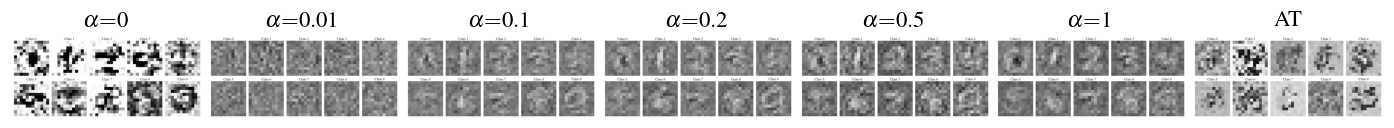

Saved figures/jem_mnist/sampling/mnist_samples.pdf


In [9]:
import torch
from baselines.jem.generate import sample_and_plot

N_PER_CLASS = 64
SAMPLE_STEPS = 1000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

save_dir = PROJECT_ROOT / "figures/jem_mnist/sampling"
sample_images = []
for key, regime, alpha in MODEL_ORDER:
    best = sel(key).loc[sel(key)["acc"].idxmax()]
    run_dir = PROJECT_ROOT / SWEEP_DIRS[key] / str(best["run_name"])
    model_dir = save_dir / key
    print(f"{MODEL_LABEL[key]}: {run_dir} (acc={best['acc']:.4f}, device={DEVICE})")
    fig = sample_and_plot(run_dir, n_per_class=N_PER_CLASS, steps=SAMPLE_STEPS,
                          save_dir=model_dir, device=DEVICE)
    fig.canvas.draw()
    sample_images.append((key, np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()))
    plt.close(fig)

fig, axes = plt.subplots(1, len(sample_images), figsize=(2.3 * len(sample_images), 3.0), squeeze=False)
for ax, (key, image) in zip(axes[0], sample_images):
    ax.imshow(image)
    ax.set_title(MODEL_LABEL[key]); ax.axis("off")
fig.subplots_adjust(wspace=0.03)
save(fig, save_dir / "mnist_samples.pdf")

---
## §2  Alpha curves — accuracy and loss

The same six alpha sweeps and filenames as MPS:

- `alpha_curve_accuracy.pdf`: Clean, Rob., both likelihood radii and Purif. (samp., $k=6$).
- `alpha_curve_nll.pdf`: discriminative loss and the JEM generative CD surrogate, measured post-hoc with a fixed validation SGLD chain for every $\alpha$ (including $\alpha=0$).

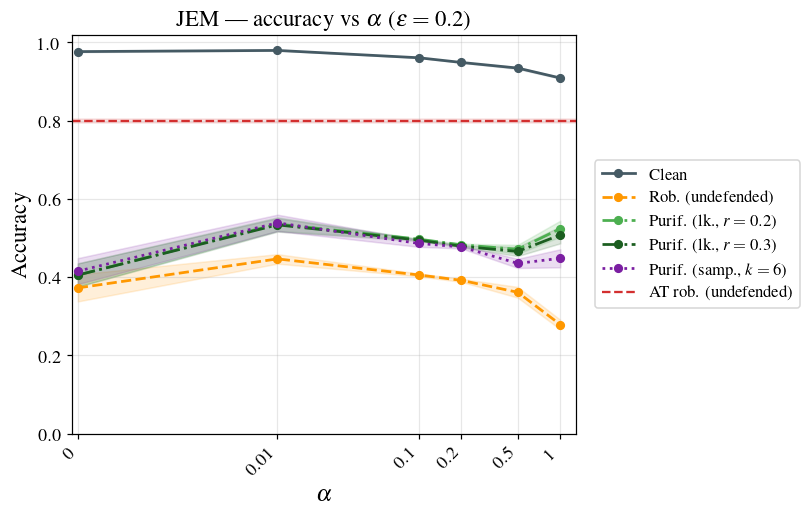

Saved figures/jem_mnist/alpha/alpha_curve_accuracy.pdf


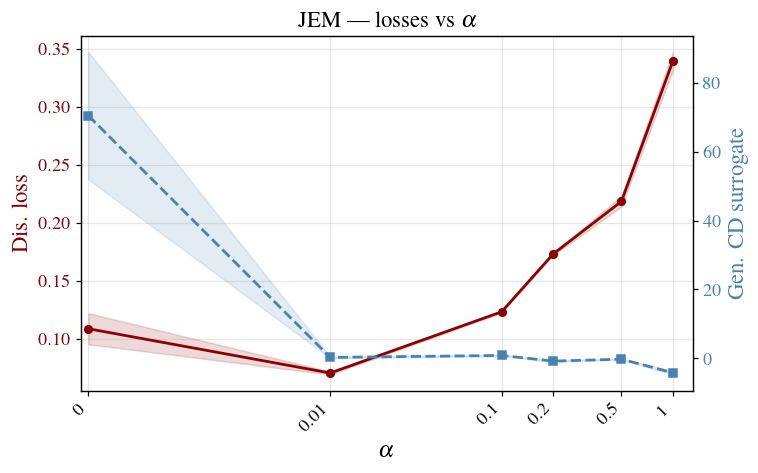

Saved figures/jem_mnist/alpha/alpha_curve_nll.pdf


In [10]:
CURVES = [
    ("Clean", "acc", "#455A64", "-"),
    ("Rob. (undefended)", f"rob/{EPS_MAIN}", "#FF9800", "--"),
    (r"Purif. (lk., $r=0.2$)", f"uq_purify_acc/{EPS_MAIN}/0.2", "#4CAF50", "-."),
    (r"Purif. (lk., $r=0.3$)", f"uq_purify_acc/{EPS_MAIN}/0.3", "#1B5E20", "-."),
    (rf"Purif. (samp., $k={SGLD_K}$)", f"sgld_purify_acc/{EPS_MAIN}/{SGLD_K}", "#7B1FA2", ":"),
]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for label, col, color, ls in CURVES:
    stats = [ms(sel(key), col) for key in NAT_KEYS]
    mean, std = map(np.asarray, zip(*stats))
    errline(ax, np.asarray(list(ALPHA_OF.values())), mean, np.nan_to_num(std), color, label, ls=ls)
at_mean, at_std = ms(sel("at_seed_sweep"), f"rob/{EPS_MAIN}")
ax.axhline(at_mean, color="#D32F2F", ls="--", lw=1.5, label="AT rob. (undefended)")
ax.axhspan(at_mean - at_std, at_mean + at_std, color="#D32F2F", alpha=0.12)
setup_alpha_axis(ax); ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax.set_title(rf"JEM — accuracy vs $\alpha$ ($\varepsilon={EPS_MAIN}$)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout(); save(fig, fig_path("alpha", "alpha_curve_accuracy.pdf"))

fig, left = plt.subplots(figsize=(7, 4.4)); right = left.twinx()
for ax, col, color, ls, marker in ((left, "dis_loss", "darkred", "-", "o"),
                                    (right, "gen_loss", "steelblue", "--", "s")):
    stats = [ms(sel(key), col) for key in NAT_KEYS]
    mean, std = map(np.asarray, zip(*stats))
    errline(ax, np.asarray(list(ALPHA_OF.values())), mean, np.nan_to_num(std), color, col, ls, marker)
setup_alpha_axis(left); left.set_ylabel("Dis. loss", color="darkred")
right.set_ylabel("Gen. CD surrogate", color="steelblue")
left.tick_params(axis="y", labelcolor="darkred"); right.tick_params(axis="y", labelcolor="steelblue")
left.grid(True, alpha=0.3); left.set_title(r"JEM — losses vs $\alpha$")
fig.tight_layout(); save(fig, fig_path("alpha", "alpha_curve_nll.pdf"))

---
## §3  Defense comparison (model × defense, per attack strength)

The MPS bar groups and five headline models are preserved: **Clean**, **Rob.**, **Purif. (lk.)**, **Purif. (samp., $k=6$)** and **Accept ($q=10\%$)**. Outputs: `defense_comparison_eps{0.1,0.2,0.3}.pdf`.

In [11]:
from baselines.jem.plots import plot_defense_comparison

MODELS = {
    r"$\alpha{=}0$": ANALYSIS_CSV["seed_sweep_a0"],
    r"$\alpha{=}0.01$": ANALYSIS_CSV["seed_sweep_a001"],
    r"$\alpha{=}0.5$": ANALYSIS_CSV["seed_sweep_a05"],
    r"$\alpha{=}1$": ANALYSIS_CSV["seed_sweep_a1"],
    "AT": ANALYSIS_CSV["at_seed_sweep"],
}
plot_defense_comparison(
    MODELS,
    PROJECT_ROOT / "figures/jem_mnist/robustness",
    radius=PURIFY_RADIUS,
    sampling_sweep=SGLD_K,
    percentile=10,
)

[PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/robustness/defense_comparison_eps0.1.pdf'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/robustness/defense_comparison_eps0.2.pdf'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/robustness/defense_comparison_eps0.3.pdf')]

In [12]:
# The MPS notebook's compact and full model-comparison tables (SGLD replaces Gibbs).
TABLE_METRICS = [
    ("Clean", "Clean", "acc", False),
    ("Rob.", "Rob.", "rob/{eps}", False),
    (r"Purif. (lk., $r=0.2$)", "Purif lk r.2", "uq_purify_acc/{eps}/0.2", False),
    (r"Purif. (lk., $r=0.3$)", "Purif lk r.3", "uq_purify_acc/{eps}/0.3", False),
    (rf"Purif. (samp., $k={SGLD_K}$)", f"Purif Sk{SGLD_K}", f"sgld_purify_acc/{{eps}}/{SGLD_K}", False),
    (r"Det. rate ($q=10\%$)", "Det rate", f"uq_detection/{DET_PCT}/{{eps}}", False),
    (r"Acc. passed ($q=10\%$)", "Acc passed", f"uq_det_err_passed/{DET_PCT}/{{eps}}", True),
]

def table_stat(key, template, flip, eps):
    return ms(sel(key), template.format(eps=eps), flip)

def best_index(values):
    valid = [(value, index) for index, value in enumerate(values) if np.isfinite(value)]
    return max(valid)[1] if valid else -1

def tex_cell(mean, std, bold=False):
    if not np.isfinite(mean): return "---"
    body = f"{mean:.3f} \\pm {std:.3f}"
    return f"$\\mathbf{{{body}}}$" if bold else f"${body}$"

def txt_cell(mean, std, best=False):
    if not np.isfinite(mean): return "---"
    return f"{mean:.3f}±{std:.3f}" + ("*" if best else "")

table_dir = FIG_ROOT / "tables"; table_dir.mkdir(parents=True, exist_ok=True)
grid = [[table_stat(key, template, flip, EPS_MAIN) for _, _, template, flip in TABLE_METRICS]
        for key in MODEL_KEYS]
best = [best_index([grid[i][j][0] for i in range(len(MODEL_KEYS))])
        for j in range(len(TABLE_METRICS))]
latex = [r"\begin{table}[htbp]", r"\centering", r"\small",
         r"\begin{tabular}{@{}l" + "r" * len(TABLE_METRICS) + r"@{}}", r"\toprule",
         "Model & " + " & ".join(label for label, *_ in TABLE_METRICS) + " " + 2 * chr(92), r"\midrule"]
for i, key in enumerate(MODEL_KEYS):
    latex.append(MODEL_LABEL[key] + " & " + " & ".join(
        tex_cell(mean, std, best[j] == i) for j, (mean, std) in enumerate(grid[i])) + " " + 2 * chr(92))
latex += [r"\bottomrule", r"\end{tabular}",
          rf"\caption{{JEM defenses at $\varepsilon={EPS_MAIN}$, mean $\pm$ std over five seeds.}}",
          r"\label{tab:jem_mnist_r12_models}", r"\end{table}"]
(table_dir / f"model_comparison_eps{EPS_MAIN}.tex").write_text("\n".join(latex) + "\n")
width = 17
plain = [f"JEM defenses at eps={EPS_MAIN}; * = best per column",
         f"{'Model':<14}" + "".join(f"{short:<{width}}" for _, short, *_ in TABLE_METRICS)]
for i, key in enumerate(MODEL_KEYS):
    plain.append(f"{MODEL_PLAIN[key]:<14}" + "".join(
        f"{txt_cell(mean, std, best[j] == i):<{width}}" for j, (mean, std) in enumerate(grid[i])))
(table_dir / f"model_comparison_eps{EPS_MAIN}.txt").write_text("\n".join(plain) + "\n")

data = [[[table_stat(key, template, flip, eps) for eps in EPS_LIST]
         for _, _, template, flip in TABLE_METRICS] for key in MODEL_KEYS]
best = [[best_index([data[i][j][e][0] for i in range(len(MODEL_KEYS))])
         for e in range(len(EPS_LIST))] for j in range(len(TABLE_METRICS))]
latex = [r"\begin{table}[htbp]", r"\centering", r"\small",
         r"\begin{tabular}{@{}llrrr@{}}", r"\toprule",
         "Model & Metric & " + " & ".join(rf"$\varepsilon={eps}$" for eps in EPS_LIST) + " " + 2 * chr(92),
         r"\midrule"]
for i, key in enumerate(MODEL_KEYS):
    for j, (label, *_rest) in enumerate(TABLE_METRICS):
        model = rf"\multirow{{{len(TABLE_METRICS)}}}{{*}}{{{MODEL_LABEL[key]}}}" if j == 0 else ""
        cells = [tex_cell(*data[i][j][e], bold=best[j][e] == i) for e in range(len(EPS_LIST))]
        latex.append(f"{model} & {label} & " + " & ".join(cells) + " " + 2 * chr(92))
    if i < len(MODEL_KEYS) - 1: latex.append(r"\cmidrule(lr){1-5}")
latex += [r"\bottomrule", r"\end{tabular}",
          r"\caption{JEM defenses across attack budgets, mean $\pm$ std over five seeds.}",
          r"\label{tab:jem_mnist_r12_models_all_eps}", r"\end{table}"]
(table_dir / "model_comparison.tex").write_text("\n".join(latex) + "\n")
plain = ["JEM defenses across attack budgets; * = best per metric/epsilon"]
for i, key in enumerate(MODEL_KEYS):
    for j, (_, short, *_rest) in enumerate(TABLE_METRICS):
        label = MODEL_PLAIN[key] if j == 0 else ""
        plain.append(f"{label:<14}{short:<16}" + "".join(
            f"{txt_cell(*data[i][j][e], best=best[j][e] == i):<{width}}" for e in range(len(EPS_LIST))))
(table_dir / "model_comparison.txt").write_text("\n".join(plain) + "\n")
print("\n".join(plain))

JEM defenses across attack budgets; * = best per metric/epsilon
a=0           Clean           0.977±0.001      0.977±0.001      0.977±0.001      
              Rob.            0.841±0.012      0.373±0.035      0.075±0.015      
              Purif lk r.2    0.854±0.009      0.405±0.030      0.091±0.015      
              Purif lk r.3    0.853±0.009      0.405±0.030      0.091±0.015      
              Purif Sk6       0.875±0.008      0.415±0.033      0.091±0.017      
              Det rate        0.283±0.017      0.358±0.054      0.204±0.047      
              Acc passed      0.914±0.015*     0.448±0.046      0.076±0.018      
a=0.01        Clean           0.980±0.000*     0.980±0.000*     0.980±0.000*     
              Rob.            0.871±0.004*     0.447±0.012      0.121±0.002      
              Purif lk r.2    0.874±0.006*     0.536±0.017      0.187±0.005      
              Purif lk r.3    0.872±0.007*     0.534±0.017      0.205±0.008      
              Purif Sk6       0.88

---
## §4a  Detection — accuracy on passed samples vs ratio passed

This is the same operating-point view as `mnist.ipynb`: $x=1-$ detection rate and $y=1-$ error among accepted inputs, with one panel per attack budget.

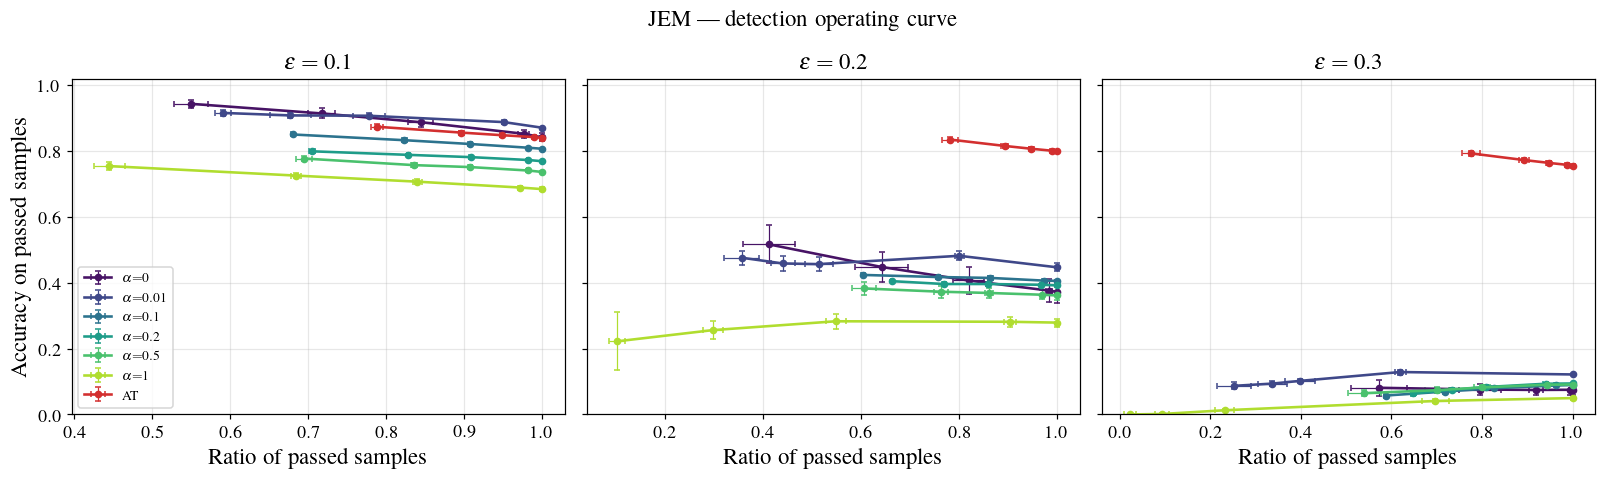

Saved figures/jem_mnist/detection/accept_acc_vs_passed_ratio.pdf


In [13]:
fig, axes = plt.subplots(1, len(EPS_LIST), figsize=(4.9 * len(EPS_LIST), 4.4), sharey=True)
for ax, eps in zip(np.atleast_1d(axes), EPS_LIST):
    for key, _, _ in MODEL_ORDER:
        q, x, y, xerr, yerr = accept_curve(sel(key), eps)
        ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=MODEL_COLOR[key], lw=1.7,
                    marker="o", ms=4, capsize=2, elinewidth=0.8, label=MODEL_LABEL[key])
    ax.set_title(rf"$\varepsilon={eps}$"); ax.set_xlabel("Ratio of passed samples")
    ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Accuracy on passed samples"); axes[0].legend(fontsize=9, loc="lower left")
fig.suptitle("JEM — detection operating curve", fontsize=15)
fig.tight_layout(); save(fig, fig_path("detection", "accept_acc_vs_passed_ratio.pdf"))

---
## §5  SGLD purification against itself

Direct counterpart of the three Gibbs figures in `mnist.ipynb`. Here $k$ is the number of locally projected SGLD sweeps, each containing 20 transitions. The $k=0$ anchor and every purified point use the same fixed `sampling_subsample`, so the comparison is paired.

- one line per model at the headline $\varepsilon$;
- one panel per $\varepsilon$;
- clean-input cost as a function of $k$.

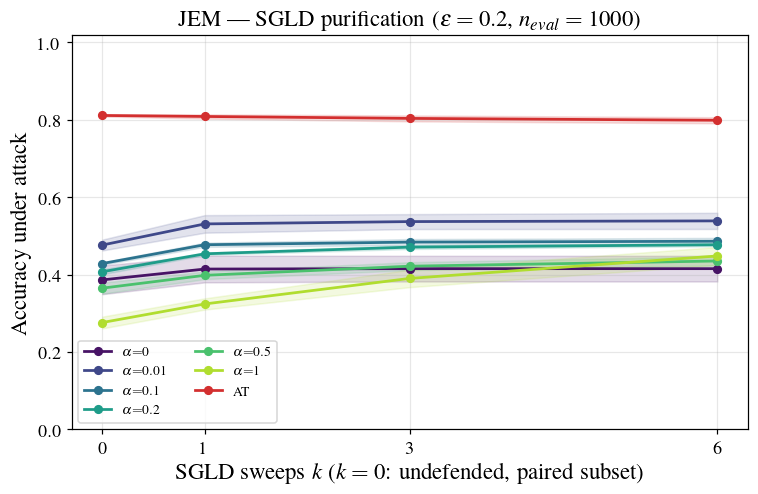

Saved figures/jem_mnist/sgld/sgld_alpha_vs_k.pdf


In [14]:
fig, ax = plt.subplots(figsize=(7, 4.6))
for key, _, _ in MODEL_ORDER:
    k, mean, std = sgld_curve(sel(key), EPS_MAIN)
    errline(ax, k, mean, std, MODEL_COLOR[key], MODEL_LABEL[key])
ax.set_xticks([0] + SGLD_KS); ax.set_xlabel("SGLD sweeps $k$   ($k=0$: undefended, paired subset)")
ax.set_ylabel("Accuracy under attack"); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax.set_title(rf"JEM — SGLD purification ($\varepsilon={EPS_MAIN}$, $n_{{eval}}={SGLD_N_EVAL}$)")
ax.legend(fontsize=9, ncol=2); fig.tight_layout()
save(fig, fig_path("sgld", "sgld_alpha_vs_k.pdf"))

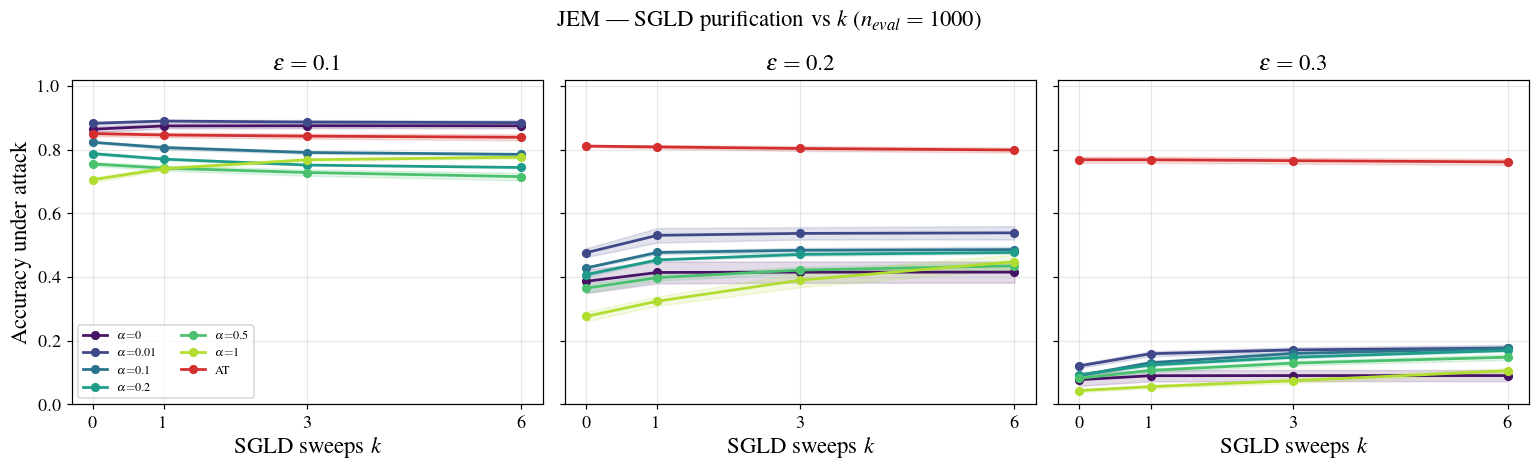

Saved figures/jem_mnist/sgld/sgld_alpha_vs_k_by_eps.pdf


In [15]:
fig, axes = plt.subplots(1, len(EPS_LIST), figsize=(4.7 * len(EPS_LIST), 4.3), sharey=True)
for ax, eps in zip(np.atleast_1d(axes), EPS_LIST):
    for key, _, _ in MODEL_ORDER:
        k, mean, std = sgld_curve(sel(key), eps)
        errline(ax, k, mean, std, MODEL_COLOR[key], MODEL_LABEL[key])
    ax.set_title(rf"$\varepsilon={eps}$"); ax.set_xticks([0] + SGLD_KS)
    ax.set_xlabel("SGLD sweeps $k$"); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Accuracy under attack"); axes[0].legend(fontsize=8, ncol=2)
fig.suptitle(rf"JEM — SGLD purification vs $k$ ($n_{{eval}}={SGLD_N_EVAL}$)", fontsize=15)
fig.tight_layout(); save(fig, fig_path("sgld", "sgld_alpha_vs_k_by_eps.pdf"))

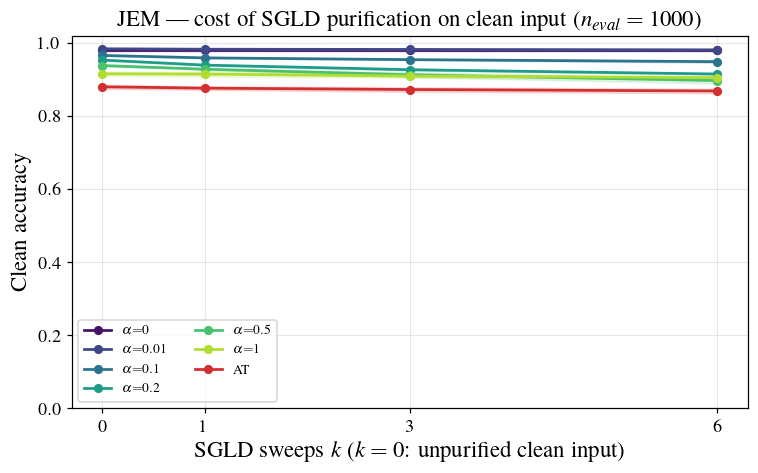

Saved figures/jem_mnist/sgld/sgld_clean_cost.pdf


In [16]:
fig, ax = plt.subplots(figsize=(7, 4.4))
for key, _, _ in MODEL_ORDER:
    k, mean, std = sgld_curve(sel(key), eps=None)
    errline(ax, k, mean, std, MODEL_COLOR[key], MODEL_LABEL[key])
ax.set_xticks([0] + SGLD_KS); ax.set_xlabel("SGLD sweeps $k$   ($k=0$: unpurified clean input)")
ax.set_ylabel("Clean accuracy"); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax.set_title(rf"JEM — cost of SGLD purification on clean input ($n_{{eval}}={SGLD_N_EVAL}$)")
ax.legend(fontsize=9, ncol=2); fig.tight_layout()
save(fig, fig_path("sgld", "sgld_clean_cost.pdf"))

---
## §7  Model-comparison tables

The same full model-comparison and adaptive-attack tables as MPS, under `figures/jem_mnist/tables/`. SGLD replaces Gibbs.

In [17]:
from baselines.jem.tables import write_mnist_tables

TABLE_MODELS = {
    "seed_sweep_a0": (r"$\alpha{=}0$", ANALYSIS_CSV["seed_sweep_a0"]),
    "seed_sweep_a001": (r"$\alpha{=}0.01$", ANALYSIS_CSV["seed_sweep_a001"]),
    "seed_sweep_a01": (r"$\alpha{=}0.1$", ANALYSIS_CSV["seed_sweep_a01"]),
    "seed_sweep_a02": (r"$\alpha{=}0.2$", ANALYSIS_CSV["seed_sweep_a02"]),
    "seed_sweep_a05": (r"$\alpha{=}0.5$", ANALYSIS_CSV["seed_sweep_a05"]),
    "seed_sweep_a1": (r"$\alpha{=}1$", ANALYSIS_CSV["seed_sweep_a1"]),
    "at_seed_sweep": ("AT", ANALYSIS_CSV["at_seed_sweep"]),
}
write_mnist_tables(
    TABLE_MODELS,
    PROJECT_ROOT / "figures/jem_mnist/tables",
    radius=PURIFY_RADIUS,
    sampling_sweep=SGLD_K,
    percentile=10,
)

[PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/detection.tex'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/detection.txt'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/joint_vs_normal_eps0.1.tex'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/joint_vs_normal_eps0.2.tex'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/joint_vs_normal_eps0.3.tex'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/joint_vs_normal.txt')]

---
## §4b  Detection effectiveness vs threshold

The same likelihood-detector curves as MPS: accepted accuracy and adversarial detection rate versus clean rejection percentile. No external dataset is used. Outputs: `accept_acc_vs_threshold_{key}.pdf`.

In [18]:
from baselines.jem.plots import plot_detection_thresholds

DET_SWEEPS = {
    "seed_sweep_a0": (r"$\alpha{=}0$", ANALYSIS_CSV["seed_sweep_a0"]),
    "seed_sweep_a001": (r"$\alpha{=}0.01$", ANALYSIS_CSV["seed_sweep_a001"]),
    "seed_sweep_a1": (r"$\alpha{=}1$", ANALYSIS_CSV["seed_sweep_a1"]),
    "at_seed_sweep": ("AT", ANALYSIS_CSV["at_seed_sweep"]),
}
plot_detection_thresholds(
    DET_SWEEPS,
    PROJECT_ROOT / "figures/jem_mnist/detection",
    percentiles=(1, 5, 10, 20),
)

[PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/detection/accept_acc_vs_threshold_seed_sweep_a0.pdf'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/detection/accept_acc_vs_threshold_seed_sweep_a001.pdf'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/detection/accept_acc_vs_threshold_seed_sweep_a1.pdf'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/detection/accept_acc_vs_threshold_at_seed_sweep.pdf')]

---
## Where everything landed

```text
figures/jem_mnist/
  sampling/       mnist_samples.pdf + one cached grid per model
  alpha/          alpha_curve_accuracy.pdf · alpha_curve_nll.pdf
  robustness/     defense_comparison_eps{0.1,0.2,0.3}.pdf
  detection/      accept_acc_vs_passed_ratio.pdf
                  accept_acc_vs_threshold_{a0,a001,a1,at}.pdf
  sgld/           sgld_alpha_vs_k.pdf · sgld_alpha_vs_k_by_eps.pdf
                  sgld_clean_cost.pdf
  purify_radius/  purify_acc_vs_radius.pdf
  tables/         model_comparison.{tex,txt}
                  model_comparison_eps0.2.{tex,txt}
                  joint_vs_normal_eps{0.1,0.2,0.3}.tex
                  joint_vs_normal.txt
```

There is deliberately no bond-dimension section: every result uses the single JEM architecture `mlp_h550x480`.